# 04 · Regression: RMSE, baselines and confidence intervals

Chapter 2 walks through a regression project end to end and settles on **RMSE** as the
performance measure. scikit-learn scorers are "greater is better", so the loss appears
negated: `neg_root_mean_squared_error`. `mloptune` maximizes whatever scorer you give it,
which is why negative metrics work unchanged.

In [1]:
import warnings

warnings.filterwarnings("ignore")  # hide convergence and progress-bar warnings in tutorial output

import optuna

optuna.logging.set_verbosity(optuna.logging.ERROR)  # Optuna otherwise logs every trial, and a traceback per failed one

In [2]:
import matplotlib.pyplot as plt

SERIES = ["#2a78d6", "#eb6834", "#1baf7a"]  # categorical palette, used in this fixed order
INK, INK_2, GRID = "#0b0b0b", "#52514e", "#e5e4e0"


def tidy(ax, title, xlabel, ylabel):
    """Recessive axes and grid so the data, not the frame, carries the chart."""
    ax.set_title(title, loc="left", color=INK, fontsize=12, pad=12)
    ax.set_xlabel(xlabel, color=INK_2)
    ax.set_ylabel(ylabel, color=INK_2)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(GRID)
    ax.tick_params(colors=INK_2)
    ax.grid(axis="y", color=GRID, linewidth=1)
    ax.set_axisbelow(True)

## 1. A linear baseline, then a tuned gradient-boosting model

The book's advice: get a simple model working first, then shortlist and fine-tune.
The default regression scorer is `neg_mean_squared_error`; we ask for RMSE explicitly
because it is in the units of the target.

In [3]:
from sklearn.datasets import load_diabetes

from mloptune import FineTuneConfig, FineTuner

diabetes = load_diabetes()
X, y = diabetes.data, diabetes.target

linear = FineTuner(
    FineTuneConfig("LinearRegression", "regression", "tutorial-04-diabetes", scoring="neg_root_mean_squared_error")
).run(X, y)
print(f"LinearRegression  validation RMSE={-linear.validation_score:.2f}  test RMSE={-linear.test_score:.2f}")

LinearRegression  validation RMSE=61.84  test RMSE=51.90


In [4]:
hgb_config = FineTuneConfig(
    model_name="HistGradientBoostingRegressor",
    problem_type="regression",
    experiment_name="tutorial-04-diabetes",  # same name -> same split as the baseline
    scoring="neg_root_mean_squared_error",
    n_trials=20,
    n_startup_trials=6,
    search_space={
        "learning_rate": {"type": "float", "low": 0.01, "high": 0.3, "log": True},
        "max_leaf_nodes": {"type": "int", "low": 3, "high": 31},
        "min_samples_leaf": {"type": "int", "low": 5, "high": 60},
        "l2_regularization": {"type": "float", "low": 0.0, "high": 5.0},
    },
    model_kwargs={"max_iter": 200},
)
hgb = FineTuner(hgb_config).run(X, y)
print("best:", hgb.best_params)
print(f"HistGradientBoosting  validation RMSE={-hgb.validation_score:.2f}  test RMSE={-hgb.test_score:.2f}")

best: {'learning_rate': 0.023487083552625142, 'max_leaf_nodes': 18, 'min_samples_leaf': 44, 'l2_regularization': 2.8088973331260245}
HistGradientBoosting  validation RMSE=61.42  test RMSE=52.72


On this small, noisy dataset the tuned booster does not beat plain linear regression by
much, if at all. That is a real result, not a failure: the book's California-housing
example shows the same thing before feature engineering. Regularized linear models are
often the right answer for a few hundred rows.

## 2. Regularized linear models

`Ridge` and `Lasso` have one important hyperparameter, `alpha`, that spans orders of
magnitude. A log-uniform search is the right tool.

In [5]:
for model_name in ("Ridge", "Lasso"):
    config = FineTuneConfig(
        model_name=model_name,
        problem_type="regression",
        experiment_name="tutorial-04-diabetes",
        scoring="neg_root_mean_squared_error",
        n_trials=15,
        search_space={"alpha": {"type": "float", "low": 1e-3, "high": 1e2, "log": True}},
        model_kwargs={"max_iter": 10000},
    )
    r = FineTuner(config).run(X, y)
    print(f"{model_name:6s} alpha={r.best_params['alpha']:.4f}  validation RMSE={-r.validation_score:.2f}  test RMSE={-r.test_score:.2f}")

Ridge  alpha=0.0736  validation RMSE=61.48  test RMSE=52.19
Lasso  alpha=0.1627  validation RMSE=59.68  test RMSE=52.06


## 3. Look at the predictions, not just the score

Rebuild the test split from the result's seed (no stratification for regression) and plot
predicted against actual. Points near the diagonal are good predictions.

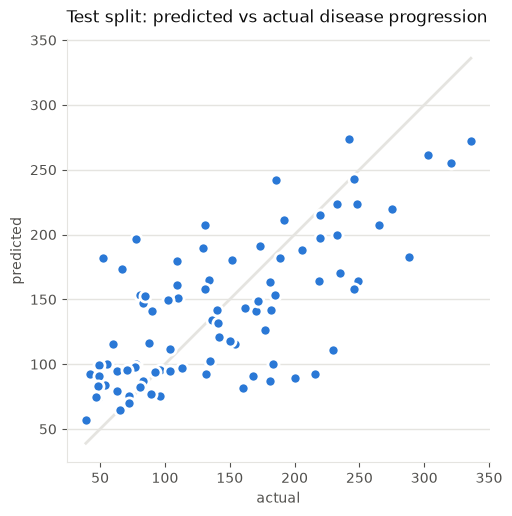

In [6]:
from mloptune import split_dataset

split = split_dataset(X, y, test_size=0.2, validation_size=0.2, random_state=hgb.seed)
y_true = split["y_test"]
y_pred = hgb.model.predict(split["X_test"])

fig, ax = plt.subplots(figsize=(5.5, 5.5))
lo, hi = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
ax.plot([lo, hi], [lo, hi], color=GRID, linewidth=2, zorder=1)
ax.scatter(y_true, y_pred, s=64, color=SERIES[0], edgecolor="white", linewidth=2, zorder=2)
ax.set_aspect("equal")
tidy(ax, "Test split: predicted vs actual disease progression", "actual", "predicted")
plt.show()

## 4. How precise is the test RMSE?

Chapter 2 ends its evaluation with a 95 % confidence interval for the generalization
error using `scipy.stats.t.interval` on the squared errors. Same recipe here.

In [7]:
import numpy as np
from scipy import stats

squared_errors = (y_pred - y_true) ** 2
interval = np.sqrt(stats.t.interval(0.95, len(squared_errors) - 1, loc=squared_errors.mean(), scale=stats.sem(squared_errors)))
print(f"test RMSE = {np.sqrt(squared_errors.mean()):.2f}   95% CI = [{interval[0]:.2f}, {interval[1]:.2f}]")

test RMSE = 52.72   95% CI = [44.47, 59.85]


With 89 test rows the interval is wide. Two models whose RMSEs differ by a few units
are not distinguishable on this test set, which is worth remembering before declaring a
winner.

## 5. pandas inputs keep feature names

Pass a DataFrame and the fitted model records `feature_names_in_`, which makes
feature-importance or coefficient tables readable.

In [8]:
import pandas as pd

X_df = pd.DataFrame(X, columns=diabetes.feature_names)
y_s = pd.Series(y, name="progression")

ridge = FineTuner(
    FineTuneConfig("Ridge", "regression", "tutorial-04-diabetes", scoring="neg_root_mean_squared_error",
                   n_trials=8, search_space={"alpha": {"type": "float", "low": 1e-3, "high": 1e2, "log": True}})
).run(X_df, y_s)

coefficients = pd.Series(ridge.model.coef_, index=ridge.model.feature_names_in_).sort_values(key=abs, ascending=False)
coefficients.round(1)

s5     536.9
bmi    514.5
bp     329.0
sex   -231.6
s1    -192.9
s4     165.7
s3    -112.9
s6      90.0
s2     -55.2
age      9.3
dtype: float64

## 6. Multi-output targets

A 2-D `y` works for estimators that support it natively (`RandomForestRegressor`,
`Ridge`, `KNeighborsRegressor`, ...). Scoring uses scikit-learn's default averaging across
outputs.

In [9]:
from sklearn.datasets import make_regression

X_multi, y_multi = make_regression(n_samples=400, n_features=8, n_targets=2, noise=10, random_state=0)
multi = FineTuner(
    FineTuneConfig("RandomForestRegressor", "regression", "tutorial-04-multi", scoring="neg_root_mean_squared_error",
                   n_trials=4, search_space={"max_depth": {"type": "int", "low": 3, "high": 12}},
                   model_kwargs={"n_estimators": 60})
).run(X_multi, y_multi)
print("prediction shape:", multi.model.predict(X_multi[:5]).shape, "| test RMSE:", round(-multi.test_score, 2))

prediction shape: (5, 2) | test RMSE: 67.5


## Takeaways

- Ask for `neg_root_mean_squared_error` (or `neg_mean_absolute_error` when outliers matter) and negate it back.
- Run a linear baseline under the same `experiment_name` so the test rows are identical.
- Report a confidence interval; a single RMSE on a small test set is a noisy estimate.